# Problem Statement : Medical Insurence Premium


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Inspection

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
data.shape

(1338, 7)

In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(1)

# EDA

## Univariate Analysis

## Numerical Columns

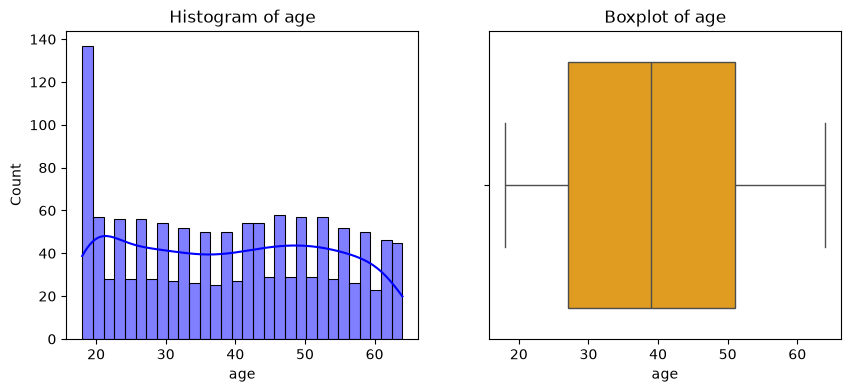

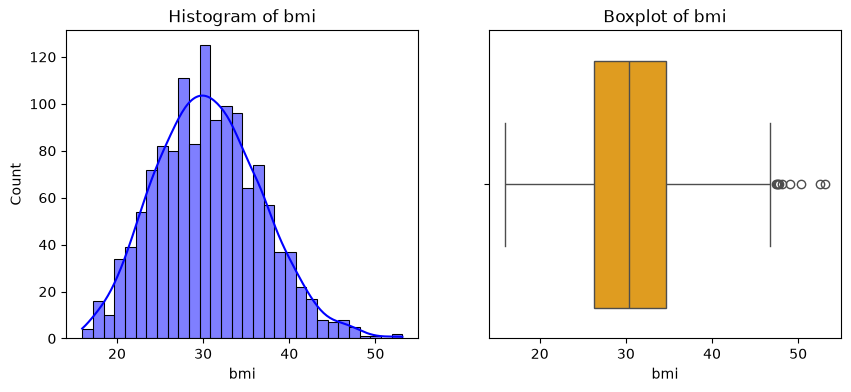

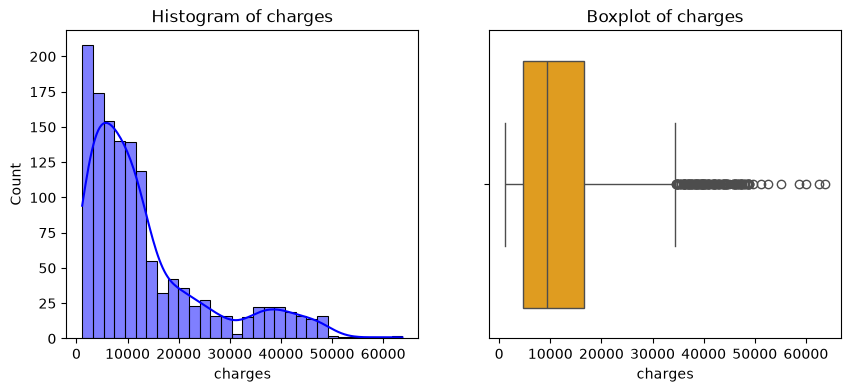

In [9]:
# Plot histograms and boxplots
numeric_features = ['age', 'bmi','charges']

for feature in numeric_features:
    plt.figure(figsize=(10, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')

    plt.show()


## Categorical Columns

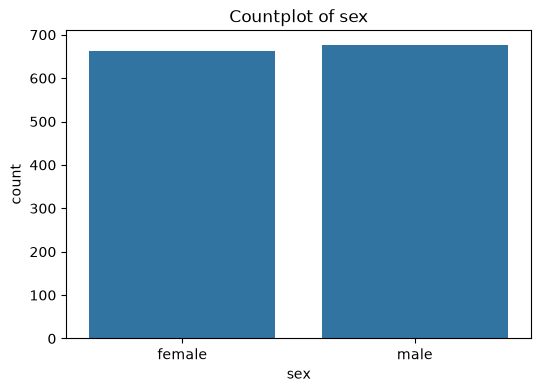

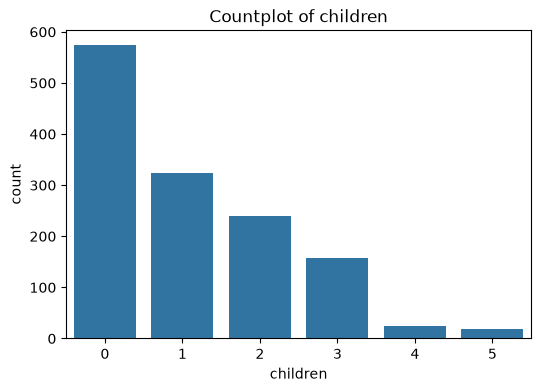

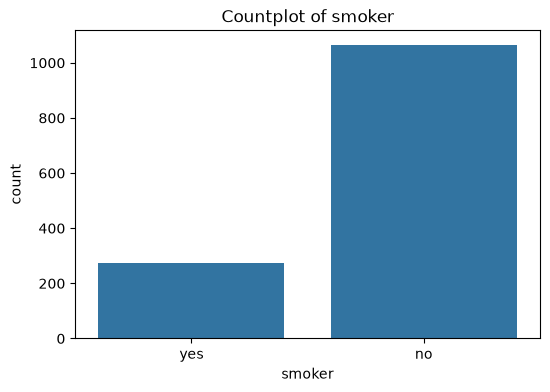

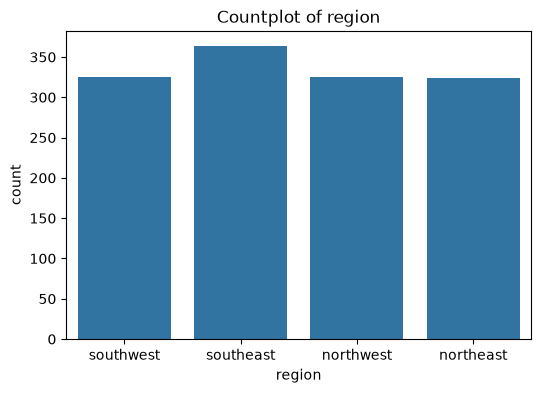

In [10]:
# Plot bar plots
categorical_features = ['sex','children', 'smoker', 'region']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=feature)
    plt.title(f'Countplot of {feature}')
    plt.show()

## Bivariate Analysis

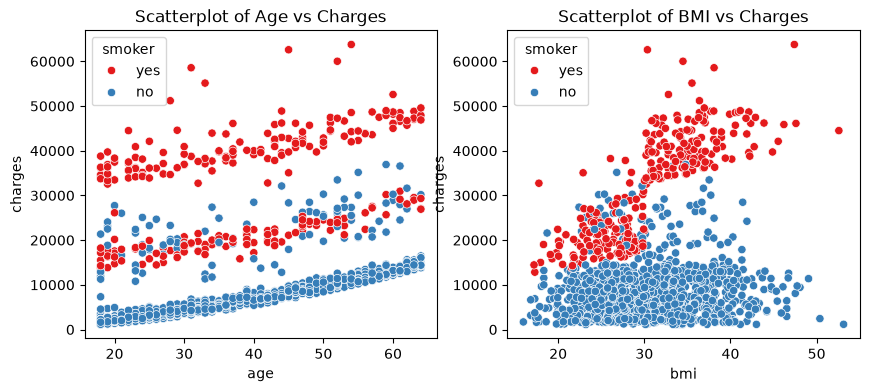

In [11]:
# Scatterplots for charges vs other numeric features
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
sns.scatterplot(data=data, x='age', y='charges', hue='smoker', palette='Set1')
plt.title(f'Scatterplot of Age vs Charges')

plt.subplot(1,2,2)
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker', palette='Set1')
plt.title(f'Scatterplot of BMI vs Charges')

plt.show()

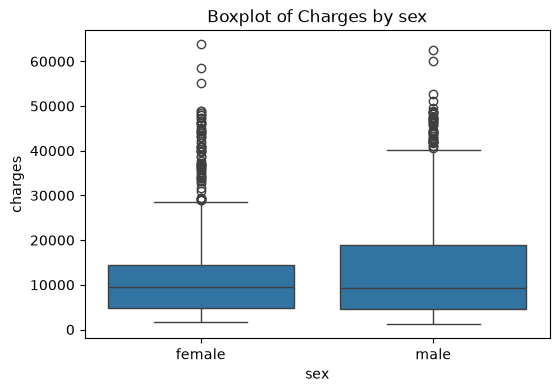

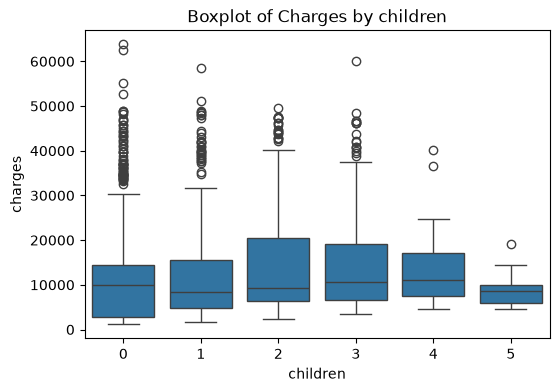

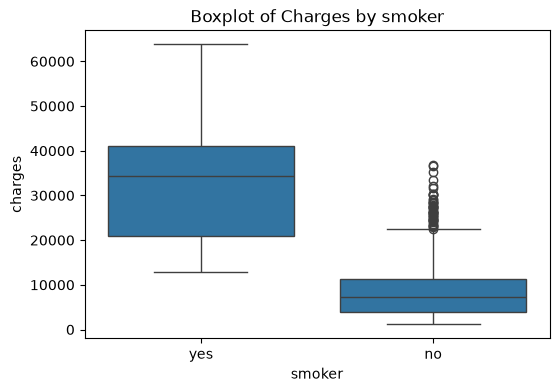

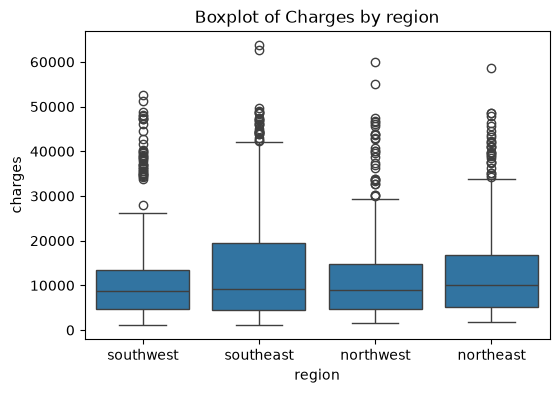

In [12]:
# Boxplots for charges across categories
categorical_features = ['sex','children','smoker', 'region']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=feature, y='charges')
    plt.title(f'Boxplot of Charges by {feature}')
    plt.show()

## One hot encoding

In [13]:
from sklearn.preprocessing import OneHotEncoder

In [14]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
# apply one hot encoding and replace data
encoded_df = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True).astype(int)
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


## Split Data

In [16]:
X = encoded_df.drop(['charges'], axis = 1)
y = encoded_df['charges']

In [17]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30,3,1,0,1,0,0
1334,18,31,0,0,0,0,0,0
1335,18,36,0,0,0,0,1,0
1336,21,25,0,0,0,0,0,1


In [18]:
y

0       16884
1        1725
2        4449
3       21984
4        3866
        ...  
1333    10600
1334     2205
1335     1629
1336     2007
1337    29141
Name: charges, Length: 1338, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 257.1 , 335.63, 427.59,...,-364.21,-667.64,-819.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.173e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [22]:
y_pred = lr.predict(X_test)

In [23]:
y_pred

array([ 9087.64215363,  7232.55948323, 36744.39282136,  9390.86060464,
       26835.96961506, 10700.88438873,   176.85511159, 16763.42629132,
        1176.75821394, 11169.05006058, 28141.94818892,  9355.95788892,
        5221.40321606, 38448.8671946 , 40094.17744513, 36935.83914845,
       15154.15405998, 35854.24430695,  9256.40504231, 31345.37256898,
        3720.33899543, 10086.00383365,  2389.24817343,  7018.12055439,
       11443.40843791, 12895.76372111, 14625.6227313 ,  6201.46301286,
        9937.46817478,  2284.12664592,  9180.25612059, 12967.21335176,
        4415.21189286,  3280.78184264,  4616.51137491, 12914.07103691,
        2005.75807266,  8668.775376  , 33415.56094315, 32673.29028852,
        3873.19203608,  4379.17387366, 14024.82770535, 11450.34188499,
        8673.91733215, 12093.78520875,  5238.19686233,  3218.05521838,
       35328.14327403,  9166.62577563, 15884.51962992,  2376.08281379,
       12380.50385494,  1609.23655956, 13396.31680531, 12705.29630435,
      

In [24]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 33566439.73530043


The `Mean Squared Error (MSE)` value of 32,201,893.45 indicates the average squared difference between actual and predicted insurance charges. A large MSE suggests the model might be underperforming or not well-tuned.

## Steps to Improve the Model:

1. `Feature Engineering`: Check for missing important variables or transformations (e.g. log transformation).
2. `Data Scaling`: Ensure numerical features like age, bmi, etc., are scaled properly.
3. `Outlier Treatment`: Remove or handle extreme values that may skew predictions.
4. Try feature selection or regularization.

In [25]:
encoded_df['charges'] = np.log(encoded_df['charges'])
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,9.734122,0,1,0,0,1
1,18,33,1,7.452982,1,0,0,1,0
2,28,33,3,8.400435,1,0,0,1,0
3,33,22,0,9.998070,1,0,1,0,0
4,32,28,0,8.259976,1,0,1,0,0


In [26]:
X = encoded_df.drop(['charges'], axis=1)
y = encoded_df['charges']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.03, 0.01, 0.09,...,-0.06,-0.14,-0.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [29]:
y_pred = lr.predict(X_test)

In [30]:
y_pred

array([ 9.11912015,  8.63756399, 11.09417094,  9.1154333 ,  9.54655723,
        8.68361266,  7.94649569,  9.61747471,  8.24293292,  9.25898673,
       10.03890426,  8.91961939,  8.39621517, 10.81806343, 10.99269899,
       10.70535447,  9.35059662, 10.65991337,  8.96488232, 10.3748996 ,
        8.48718898,  8.94843001,  7.91408642,  8.33662962,  9.36755637,
        9.33746125,  9.46069735,  8.60698325,  9.20122231,  7.86617603,
        9.06431414,  9.37043546,  8.09764821,  8.5601349 ,  8.24640301,
        9.05008437,  8.09506604,  8.88938878, 10.74851796, 10.19523344,
        8.42400214,  8.18989074,  9.41625275,  9.2830181 ,  8.63306085,
        9.33588616,  8.34971807,  8.38998879, 10.62010949,  8.6053592 ,
        9.56339114,  7.94513537,  9.01672892,  7.94850528,  9.22211515,
        9.3112575 ,  8.34591735, 10.27604821,  9.36499506,  9.31681036,
        9.50904989,  8.71342744,  9.71190828,  8.94658826,  9.24175896,
        8.38811469,  9.83680471,  9.25398848,  8.24456126,  8.13

In [31]:
y_test

764      9.115480
887      8.570165
890     10.286366
1293     9.137877
259     10.426736
          ...    
109     10.759072
575      9.410993
535      8.710620
543     11.063038
846      9.197458
Name: charges, Length: 268, dtype: float64

In [33]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.1753822142334584


In [36]:
y_pred_original = np.exp(y_pred)
y_pred_original

array([ 9128.1666751 ,  5639.57500524, 65786.56671627,  9094.57444132,
       13996.42513666,  5905.34211737,  2825.65561898, 15025.05936822,
        3800.67103657, 10498.49014355, 22900.27634943,  7477.24274184,
        4430.26717796, 49914.33075403, 59438.59217168, 44593.9941072 ,
       11505.68592566, 42612.94527384,  7823.461013  , 32045.10123173,
        4852.20721692,  7695.80001187,  2735.54625891,  4173.99805643,
       11702.48355786, 11355.54272349, 12844.83863148,  5469.72297719,
        9909.23382323,  2607.57520959,  8641.35031612, 11736.22457855,
        3286.72928119,  5219.38521198,  3813.88260887,  8519.25668641,
        3278.25333097,  7254.58365842, 46560.97223514, 26775.25551297,
        4555.09715127,  3604.32840072, 12286.45544434, 10753.83917254,
        5614.23630524, 11337.67080109,  4228.98827721,  4402.76832724,
       40950.0983214 ,  5460.84706958, 14234.03411943,  2821.81443034,
        8239.77999042,  2831.33972686, 10118.4437855 , 11061.84967571,
      